In [1]:
pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd

df = pd.read_csv(r'C:\Users\sanya\OneDrive\Desktop\Projects\1. Sales Data Analysis\Data\Train Dataset.csv')

print(df.head())

print(df.info())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [18]:
# Check missing values
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Convert date column
df['order date'] = pd.to_datetime(df['order date'], errors='coerce')

#Exact Date
df['month'] = df['order date'].dt.to_period('M')

#Monthly Sales Trend
monthly_sales = df.groupby('month')['sales'].sum()
print(monthly_sales)

row id              0
order id            0
order date       5841
ship date           0
ship mode           0
customer id         0
customer name       0
segment             0
country             0
city                0
state               0
postal code        11
region              0
product id          0
category            0
sub-category        0
product name        0
sales               0
dtype: int64
month
2015-01    19546.1630
2015-02    11678.9940
2015-03     6716.0440
2015-04    12455.4820
2015-05    15165.0510
2015-06    11884.1690
2015-07    10075.7400
2015-08    26797.7630
2015-09    17158.9320
2015-10    10112.6410
2015-11    18349.7640
2015-12    17045.8427
2016-01    17701.6864
2016-02    13018.3150
2016-03    12207.4066
2016-04    11963.6960
2016-05    10483.4820
2016-06    13026.6682
2016-07    10706.7200
2016-08    22782.5770
2016-09    16484.9010
2016-10    12293.0380
2016-11    12139.0395
2016-12     9761.3330
2017-01    26342.5410
2017-02    42967.9150
2017-03    25

In [11]:
df.columns = df.columns.str.strip().str.lower()

In [12]:
#total sales
total_sales = df['sales'].sum()
print("Total Sales:", total_sales)

#total number of orders
total_orders = df['order id'].nunique()
print("Total Orders:", total_orders)

Total Sales: 2261536.7827
Total Orders: 4922


In [13]:
#Sales by Region
region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)
print(region_sales)

#Sales by Category
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)
print(category_sales)

region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: sales, dtype: float64
category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: sales, dtype: float64


In [14]:
#Top 5 Products
top_products = df.groupby('product name')['sales'].sum().sort_values(ascending=False).head(5)
print(top_products)

#Top 5 Cities
top_cities = df.groupby('city')['sales'].sum().sort_values(ascending=False).head(5)
print(top_cities)

product name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: sales, dtype: float64
city
New York City    252462.547
Los Angeles      173420.181
Seattle          116106.322
San Francisco    109041.120
Philadelphia     108841.749
Name: sales, dtype: float64


In [19]:
import matplotlib.pyplot as plt

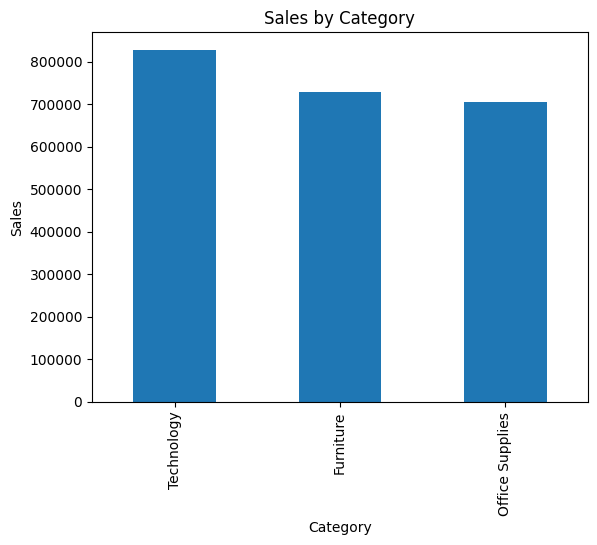

In [ ]:
category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')

# Save image
plt.savefig(r'c:\Users\sanya\OneDrive\Desktop\Projects\1. Sales Data Analysis\Images\sales_by_category.png')
plt.show()


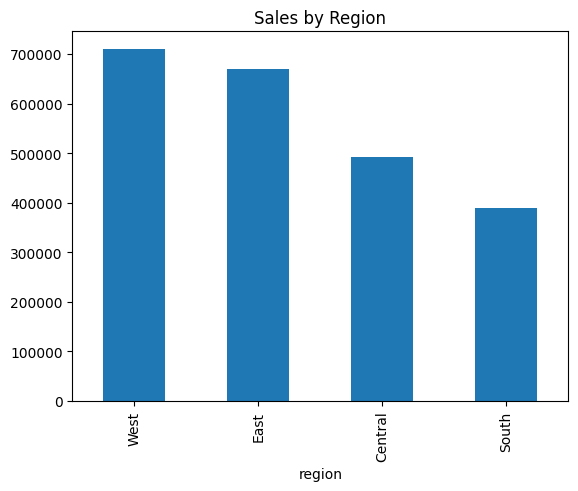

In [ ]:
region_sales.plot(kind='bar')
plt.title('Sales by Region')
# Save image
plt.savefig(r'c:\Users\sanya\OneDrive\Desktop\Projects\1. Sales Data Analysis\Images\sales_by_region.png')
plt.show()

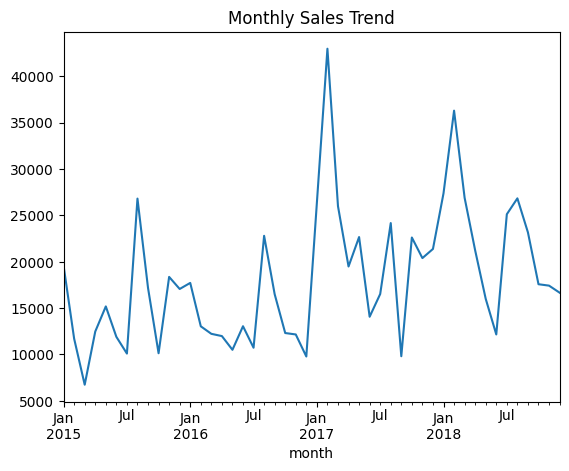

In [ ]:
monthly_sales.plot()
plt.title('Monthly Sales Trend')
# Save image
plt.savefig(r'c:\Users\sanya\OneDrive\Desktop\Projects\1. Sales Data Analysis\Images\monthly_sales_trend.png')
plt.show()

NameError: name 'df' is not defined